# 04 — Streamlit Dashboard: Design & Prototype

**Goal**: Design the real-time betting dashboard and prototype every component before building `app.py`.

**Role of this notebook**: A planning + prototype document.  
The runnable Streamlit app lives in `src/tennis_predictor/dashboard/app.py` (Gate 3).

**Relationship to notebook 03**: This notebook is a consumer of the `ingestion/` src module
built in Step 1b. It does not re-define any classes — it imports them from `tennis_predictor.ingestion`.

**Smoothing decision**: Win probability is displayed as a rolling mean (WINDOW = 20 points),
matching notebook 03's visualisation style. Rationale:
- Raw ONNX output zigzags every time the server changes (~0.60 → ~0.40 each game).
- The rolling mean reveals true momentum trends while remaining responsive.
- Same design used for the latency subplot (shows steady-state cost, not GC noise).

**Dashboard features**:
| Widget | Streamlit API | Data source |
|---|---|---|
| Match selector | `st.selectbox` | `IngestionPipeline._df_states` |
| Simulation speed | `st.slider` | passed to `MatchEventProducer.speed_factor` |
| Live chart | `st.line_chart` | rolling mean of `OddsPublisher.to_dataframe()` |
| Score ticker | `st.sidebar.metric` | `st.session_state["current_event"]` |
| Latency panel | `st.metric` | rolling mean of `OddsUpdate.latency_ms` |

**Streaming architecture**:
```
st.session_state["queue"]           EventQueue — persisted across re-renders
st.session_state["state_manager"]   GameStateManager — live score state
st.session_state["publisher"]       OddsPublisher — grows by 1 per tick
st.session_state["engine"]          InferenceEngine — loaded once at app start
      │
      ▼  (each st.rerun() tick)
queue.pop() → state.apply_event() → engine.predict() → publisher.publish()
      │
      ▼
odds_df.rolling(20).mean() → st.line_chart   # chart grows by one point
st.rerun()                                    # schedule next tick
```

## 1. Setup

In [6]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent

MODEL_PATH   = PROJECT_ROOT / "models" / "xgb_server_wins.onnx"
MAPPING_PATH = PROJECT_ROOT / "models" / "player_mapping.json"

processed_dir = PROJECT_ROOT / "data" / "data_download" / "training" / "processed"
run_dirs = sorted(processed_dir.glob("preprocessed_*"), reverse=True)
assert run_dirs, f"No preprocessed_* dirs found in {processed_dir}"
FULL_STATES_PATH = run_dirs[0] / "full_game_states.csv"

# ── Import from src ───────────────────────────────────────────────────────────
# The ingestion module is installed in editable mode via uv.
# This notebook is a thin consumer of the src library — it defines no classes.
from tennis_predictor.ingestion import IngestionConfig, IngestionPipeline

print(f"Model:       {MODEL_PATH}")
print(f"Player map:  {MAPPING_PATH}")
print(f"Game states: {FULL_STATES_PATH}")
print(f"\nIngestionPipeline imported from src ✓")

Model:       /Users/jeancharles/Desktop/NLP_ComputerVision_QualificationGoals/ml_interview_prep copy/low_latency_betting/models/xgb_server_wins.onnx
Player map:  /Users/jeancharles/Desktop/NLP_ComputerVision_QualificationGoals/ml_interview_prep copy/low_latency_betting/models/player_mapping.json
Game states: /Users/jeancharles/Desktop/NLP_ComputerVision_QualificationGoals/ml_interview_prep copy/low_latency_betting/data/data_download/training/processed/preprocessed_2026_02_15_20_02/full_game_states.csv

IngestionPipeline imported from src ✓


## 2. Match Selector Prototype

The dashboard opens with a `st.selectbox` listing all available matches, ordered
by length (most data = best live demo).

This cell shows the data behind that dropdown: a ranked catalogue built from
`IngestionPipeline._df_states` and cached in `st.session_state` at app start.

**Interview talking point**: The catalogue is built once at startup (expensive — full
CSV groupby). In production this metadata would live in a separate index table,
not computed from the raw event log on every app start.

In [7]:
# Instantiate pipeline (loads CSV + ONNX + player mapping once)
config = IngestionConfig(
    processed_csv=FULL_STATES_PATH,
    model_path=MODEL_PATH,
    player_mapping_path=MAPPING_PATH,
)
pipeline = IngestionPipeline(config)

# ── Identify "clean" matches ──────────────────────────────────────────────────
# Some matches in the Sackmann dataset have their PBP string split across
# multiple source CSV rows. The parser restarts from GameState() for each row,
# producing spurious all-zero score resets mid-match. These matches give
# incorrect score tickers and flat probability curves at reset boundaries.
#
# A reset row is any row (after the first) where ALL six score fields are
# simultaneously 0 — the only legitimate all-zero row is the very first point
# of the match (row_num=0). Adding points_p1/p2=0 is the key: once the first
# point is played they become non-zero, so the condition can never fire again
# in a clean match.
_df      = pipeline._df_states
_row_num = _df.groupby("match_id").cumcount()   # 0-based position within match

_is_reset_row = (
    (_row_num > 0) &
    (_df["sets_p1"]    == 0) & (_df["sets_p2"]    == 0) &
    (_df["games_p1"]   == 0) & (_df["games_p2"]   == 0) &
    (_df["points_p1"]  == 0) & (_df["points_p2"]  == 0)
)
_clean_flags = (
    ~_df.assign(_reset=_is_reset_row)
    .groupby("match_id")["_reset"].any()
).rename("is_clean")

# ── Build match catalogue ─────────────────────────────────────────────────────
match_catalogue = (
    pipeline._df_states
    .groupby("match_id")
    .agg(
        n_points=("server_wins",  "count"),
        player_1=("player_1",     "first"),
        player_2=("player_2",     "first"),
        sets_p1 =("sets_p1",      "max"),
        sets_p2 =("sets_p2",      "max"),
    )
    .sort_values("n_points", ascending=False)
    .reset_index()
    .join(_clean_flags, on="match_id")
)
match_catalogue["label"] = (
    match_catalogue["player_1"] + " vs " + match_catalogue["player_2"]
    + "  (" + match_catalogue["n_points"].astype(str) + " pts, "
    + match_catalogue["sets_p1"].astype(str) + "-"
    + match_catalogue["sets_p2"].astype(str) + " sets)"
)

clean_catalogue = match_catalogue[match_catalogue["is_clean"]]

print(f"Total matches:  {len(match_catalogue):,}")
print(f"Clean matches:  {len(clean_catalogue):,}  (no game-state reset artifact)")
print()
print("Top 10 longest CLEAN matches (best for live demo):")
print(clean_catalogue[["label", "n_points"]].head(10).to_string(index=False))

# Default: longest clean match
MATCH_ID = clean_catalogue["match_id"].iloc[0]
LABEL    = clean_catalogue["label"].iloc[0]
print(f"\nSelected: {LABEL}")

Total matches:  92,415
Clean matches:  92,274  (no game-state reset artifact)

Top 10 longest CLEAN matches (best for live demo):
                                                     label  n_points
           Marin Cilic vs Sam Querrey  (499 pts, 5-1 sets)       499
        Gilles Simon vs Daniel Brands  (461 pts, 2-4 sets)       461
     Paul-Henri Mathieu vs John Isner  (450 pts, 1-5 sets)       450
     Ivo Karlovic vs Horacio Zeballos  (450 pts, 5-2 sets)       450
             John Isner vs James Ward  (438 pts, 2-4 sets)       438
             John Isner vs Tommy Haas  (437 pts, 3-2 sets)       437
            John Isner vs Marin Cilic  (437 pts, 2-3 sets)       437
Denis Istomin vs Albert Ramos-Vinolas  (418 pts, 2-2 sets)       418
          John Isner vs Mischa Zverev  (416 pts, 3-2 sets)       416
    Jo-Wilfried Tsonga vs Sam Querrey  (411 pts, 4-2 sets)       411

Selected: Marin Cilic vs Sam Querrey  (499 pts, 5-1 sets)


## 3. Run Match via IngestionPipeline

In the dashboard, `IngestionPipeline.run_match()` would run synchronously to
pre-populate the `EventQueue` at match start. The Streamlit re-render loop
then consumes one event per tick.

Here we run the full replay to get the complete `odds_df` that is used to
prototype every widget in the sections below.

In [8]:
t0 = time.perf_counter()
odds_df = pipeline.run_match(MATCH_ID)
elapsed_ms = (time.perf_counter() - t0) * 1000

n = len(odds_df)
print(f"Match: {LABEL}")
print(f"Points replayed:  {n:,}")
print(f"Wall time:        {elapsed_ms:.1f} ms")
print(f"Throughput:       {n / (elapsed_ms / 1000):,.0f} points/sec")
print()
print("Odds DataFrame (first 6 rows):")
print(odds_df.head(6).to_string(index=False))

Match: Marin Cilic vs Sam Querrey  (499 pts, 5-1 sets)
Points replayed:  499
Wall time:        528.8 ms
Throughput:       944 points/sec

Odds DataFrame (first 6 rows):
 point_index  p1_win_prob  p2_win_prob  p_server_wins  latency_ms
           0     0.597718     0.402282       0.597718    0.284375
           1     0.597718     0.402282       0.597718    0.030417
           2     0.597718     0.402282       0.597718    0.019834
           3     0.597718     0.402282       0.597718    0.014958
           4     0.597718     0.402282       0.597718    0.014250
           5     0.597718     0.402282       0.597718    0.013459


## 4. Live Chart Prototype

The dashboard's main panel is a live line chart showing two rolling-mean lines
(P1 and P2 point-win probability) that grow one point per `st.rerun()` tick.

**Smoothing**: WINDOW = 20 points (same as notebook 03 section 10). This is
applied before rendering — `st.line_chart` receives the already-smoothed Series.

In Streamlit:
```python
chart_placeholder = st.empty()          # created once, updated in-place
# ... inside the re-render loop:
df = publisher.to_dataframe()
smoothed = df[["p1_win_prob", "p2_win_prob"]].rolling(WINDOW, min_periods=1).mean()
chart_placeholder.line_chart(smoothed)  # replaces previous frame, no flicker
```

Here we prototype the final state (all points replayed) with matplotlib,
matching the chart style from notebook 03 section 10.

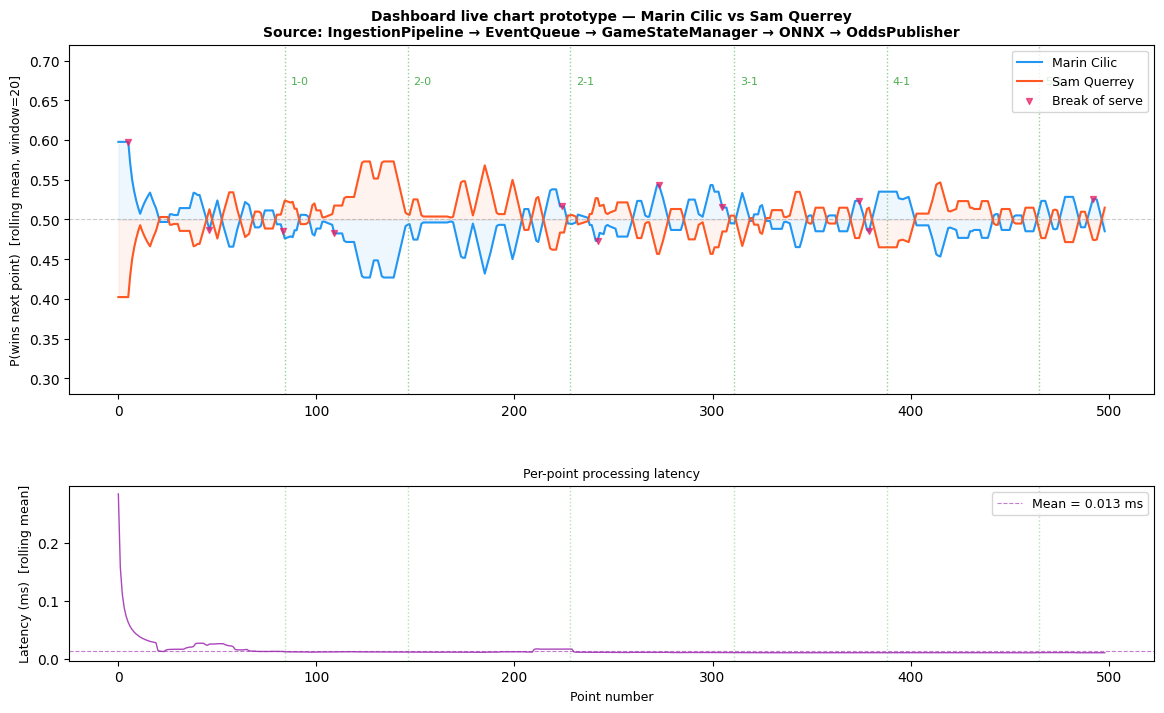

Set boundaries annotated: 6
Breaks of serve annotated: 11


In [9]:
# ── Match metadata for annotations ───────────────────────────────────────────
match_df = (
    pipeline._df_states[pipeline._df_states["match_id"] == MATCH_ID]
    .reset_index(drop=True)
)
p1_name = match_df["player_1"].iloc[0]
p2_name = match_df["player_2"].iloc[0]

# ── Smoothing (WINDOW = 20, same as notebook 03) ──────────────────────────────
WINDOW = 20
p1_smooth = odds_df["p1_win_prob"].rolling(WINDOW, min_periods=1).mean()
p2_smooth = odds_df["p2_win_prob"].rolling(WINDOW, min_periods=1).mean()

# ── Set boundaries ────────────────────────────────────────────────────────────
set_boundaries = []
prev_sets = (0, 0)
for i, row in match_df.iterrows():
    curr = (int(row["sets_p1"]), int(row["sets_p2"]))
    if curr != prev_sets:
        set_boundaries.append((i, curr))
        prev_sets = curr

# ── Break-of-serve points ─────────────────────────────────────────────────────
break_idx = match_df[
    (match_df["is_break_point"] == True) & (match_df["server_wins"] == 0)
].index.tolist()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# — Win probability (top) —————————————————————————————————————————————————————
ax1.fill_between(range(len(p1_smooth)), 0.5, p1_smooth, alpha=0.07, color="#2196F3")
ax1.fill_between(range(len(p2_smooth)), 0.5, p2_smooth, alpha=0.07, color="#FF5722")
ax1.plot(p1_smooth, color="#2196F3", linewidth=1.5, label=p1_name)
ax1.plot(p2_smooth, color="#FF5722", linewidth=1.5, label=p2_name)
ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.4)

for pt, score in set_boundaries:
    ax1.axvline(pt, color="#4CAF50", linestyle=":", alpha=0.6, linewidth=1)
    ax1.text(pt + 3, 0.67, f"{score[0]}-{score[1]}", fontsize=8, color="#4CAF50")

if break_idx:
    bp_y = [p1_smooth.iloc[i] if i < len(p1_smooth) else 0.5 for i in break_idx]
    ax1.scatter(break_idx, bp_y, marker="v", color="#E91E63",
                s=18, zorder=5, alpha=0.7, label="Break of serve")

ax1.set_ylabel("P(wins next point)  [rolling mean, window=20]", fontsize=9)
ax1.set_ylim(0.28, 0.72)
ax1.set_title(
    f"Dashboard live chart prototype — {p1_name} vs {p2_name}\n"
    f"Source: IngestionPipeline → EventQueue → GameStateManager → ONNX → OddsPublisher",
    fontsize=10, fontweight="bold"
)
ax1.legend(loc="upper right", fontsize=9)

# — Latency (bottom) ──────────────────────────────────────────────────────────
lat_smooth = odds_df["latency_ms"].rolling(WINDOW, min_periods=1).mean()
ax2.plot(lat_smooth, color="#9C27B0", linewidth=1, alpha=0.85)
ax2.axhline(odds_df["latency_ms"].mean(), color="#9C27B0", linestyle="--",
            linewidth=0.8, alpha=0.6,
            label=f"Mean = {odds_df['latency_ms'].mean():.3f} ms")
for pt, _ in set_boundaries:
    ax2.axvline(pt, color="#4CAF50", linestyle=":", alpha=0.4, linewidth=1)

ax2.set_xlabel("Point number", fontsize=9)
ax2.set_ylabel("Latency (ms)  [rolling mean]", fontsize=9)
ax2.set_title("Per-point processing latency", fontsize=9)
ax2.legend(loc="upper right", fontsize=9)

plt.show()
print(f"Set boundaries annotated: {len(set_boundaries)}")
print(f"Breaks of serve annotated: {len(break_idx)}")

## 5. Score Ticker Prototype

The dashboard sidebar displays a live score ticker — sets, games, and points for
each player — updated on every `st.rerun()` tick.

In Streamlit:
```python
with st.sidebar:
    st.metric(p1_name, fmt_score(current_event, player=1))
    st.metric(p2_name, fmt_score(current_event, player=2))
    st.caption(fmt_server(current_event, p1_name, p2_name))
```

Here we prototype `fmt_score()` and show it at 5 key moments in the match.

In [10]:
def fmt_score(row, player: int) -> str:
    """Format a score row into a sidebar metric string.

    Accepts either a pandas Series (match_df.iloc[i]) or a MatchEvent
    dataclass (st.session_state["current_event"]).
    getattr() works for both: pandas Series exposes columns as attributes;
    MatchEvent exposes them as dataclass fields.

    The CSV stores tennis scores directly (0, 15, 30, 40) — no conversion
    needed. str(int(pts)) handles all cases; deuce/advantage are captured
    separately by is_deuce / is_break_point flags.

    Example output: '1 sets  4 games  30'
    """
    sets  = int(getattr(row, f"sets_p{player}"))
    games = int(getattr(row, f"games_p{player}"))
    pts   = int(getattr(row, f"points_p{player}"))
    return f"{sets} sets  {games} games  {pts}"


def fmt_server(row, p1: str, p2: str) -> str:
    """Format a serving / tiebreak / break-point indicator line."""
    server = int(getattr(row, "serving_player"))
    name   = p1 if server == 1 else p2
    tb = "  [TIEBREAK]"  if int(getattr(row, "in_tiebreak"))    else ""
    bp = "  BREAK POINT" if int(getattr(row, "is_break_point")) else ""
    return f"Serving: {name}{tb}{bp}"


# Show ticker at 5 key moments
sample_idx = [
    0,
    len(match_df) // 4,
    len(match_df) // 2,
    3 * len(match_df) // 4,
    len(match_df) - 1,
]

print(f"Score ticker snapshots — {p1_name} vs {p2_name}")
print("=" * 62)
for idx in sample_idx:
    row      = match_df.iloc[idx]
    prob_row = odds_df[odds_df["point_index"] == idx]
    prob_str = f"{prob_row['p1_win_prob'].iloc[0]:.3f}" if not prob_row.empty else "—"
    print(f"\nPoint {idx:>4}:")
    print(f"  {p1_name:<26}: {fmt_score(row, 1)}")
    print(f"  {p2_name:<26}: {fmt_score(row, 2)}")
    print(f"  {fmt_server(row, p1_name, p2_name)}")
    print(f"  P({p1_name} wins next pt): {prob_str}")

Score ticker snapshots — Marin Cilic vs Sam Querrey

Point    0:
  Marin Cilic               : 0 sets  0 games  0
  Sam Querrey               : 0 sets  0 games  0
  Serving: Marin Cilic
  P(Marin Cilic wins next pt): 0.598

Point  124:
  Marin Cilic               : 1 sets  4 games  40
  Sam Querrey               : 0 sets  2 games  40
  Serving: Sam Querrey
  P(Marin Cilic wins next pt): 0.382

Point  249:
  Marin Cilic               : 2 sets  3 games  0
  Sam Querrey               : 1 sets  1 games  30
  Serving: Sam Querrey
  P(Marin Cilic wins next pt): 0.382

Point  374:
  Marin Cilic               : 3 sets  5 games  40
  Sam Querrey               : 1 sets  5 games  40
  Serving: Marin Cilic  BREAK POINT
  P(Marin Cilic wins next pt): 0.582

Point  498:
  Marin Cilic               : 5 sets  2 games  30
  Sam Querrey               : 1 sets  3 games  40
  Serving: Sam Querrey
  P(Marin Cilic wins next pt): 0.382


## 6. Latency Panel Prototype

The dashboard shows a `st.metric` with the rolling mean latency of the last
N points — a live KPI panel.

In Streamlit:
```python
recent = odds_df["latency_ms"].tail(20)
st.metric(
    label="Inference latency (rolling mean, last 20 pts)",
    value=f"{recent.mean():.3f} ms",
    delta=f"{recent.mean() - prev_mean:+.4f} ms",
)
```

**Interview talking point**: In production this metric is a Prometheus gauge
scraped every 15 s and visualised in Grafana. The Streamlit metric is the
local equivalent — same concept, different rendering layer.

In [11]:
lats          = odds_df["latency_ms"].values
overall_mean  = lats.mean()
ROLLING_N     = 20

# Simulate the rolling metric value at evenly spaced points in the match
sample_points = range(0, len(lats), max(1, len(lats) // 10))

print(f"Latency panel — rolling mean over last {ROLLING_N} points")
print(f"{'Point':>6}  {'Rolling mean (ms)':>18}  {'Delta vs overall':>18}")
print("-" * 46)
for i in sample_points:
    window_mean = lats[max(0, i - ROLLING_N) : i + 1].mean()
    delta = window_mean - overall_mean
    arrow = "↑" if delta > 0 else "↓"
    print(f"{i:>6}  {window_mean:>18.4f}  {arrow} {abs(delta):.4f} ms")

print()
print(f"Overall mean : {overall_mean:.4f} ms")
print(f"p50          : {np.percentile(lats, 50):.4f} ms")
print(f"p99          : {np.percentile(lats, 99):.4f} ms")
print(f"Budget target: 200 ms  →  {200 / overall_mean:,.0f}× headroom")

Latency panel — rolling mean over last 20 points
 Point   Rolling mean (ms)    Delta vs overall
----------------------------------------------
     0              0.2844  ↑ 0.2713 ms
    49              0.0252  ↑ 0.0122 ms
    98              0.0119  ↓ 0.0012 ms
   147              0.0119  ↓ 0.0012 ms
   196              0.0122  ↓ 0.0008 ms
   245              0.0115  ↓ 0.0016 ms
   294              0.0112  ↓ 0.0019 ms
   343              0.0108  ↓ 0.0023 ms
   392              0.0109  ↓ 0.0022 ms
   441              0.0108  ↓ 0.0023 ms
   490              0.0108  ↓ 0.0023 ms

Overall mean : 0.0131 ms
p50          : 0.0112 ms
p99          : 0.0504 ms
Budget target: 200 ms  →  15,300× headroom


## 7. Session State Design

Streamlit re-renders the entire script on every user interaction or `st.rerun()` call.
`st.session_state` is the only state that survives across re-renders — it is the
in-process equivalent of a Redis session store.

**Interview talking point**: The session_state pattern mirrors how stateful
stream processors work. Each re-render is a "tick" — read current state,
consume one event, write updated state. This is the actor model (Akka) or
Flink's stateful stream processing at the single-process level.

**Key rule**: Load heavy objects (`InferenceEngine`, `IngestionPipeline`)
**once** into `st.session_state`. Never re-instantiate per re-render.

In [12]:
# Session state schema — maps 1-to-1 to st.session_state keys in app.py.
# [INIT]    → set once at app start, never overwritten
# [MATCH]   → reset when user selects a new match
# [MUTABLE] → updated on every re-render tick

SESSION_STATE_SCHEMA = {
    # [INIT] Heavy singletons
    "pipeline":       "IngestionPipeline  — CSV + ONNX + player mapping, ~500 ms to load",
    "engine":         "InferenceEngine    — ONNX session, thread-safe, reused across matches",
    "catalogue":      "pd.DataFrame       — match catalogue for st.selectbox",

    # [MATCH] Per-match objects (reset on match selection)
    "match_id":       "str                — from st.selectbox",
    "p1_name":        "str",
    "p2_name":        "str",
    "queue":          "EventQueue         — pre-filled with all match events at match start",
    "state_manager":  "GameStateManager   — starts at 0-0-0, reset between matches",
    "publisher":      "OddsPublisher      — cleared at match start",

    # [MUTABLE] Updated each tick
    "current_event":  "MatchEvent | None  — drives score ticker in sidebar",
    "running":        "bool               — True = auto-advance ticks; False = paused",
    "speed_factor":   "float              — from st.slider (0.1–10.0)",
}

print("st.session_state schema:")
print()
for key, desc in SESSION_STATE_SCHEMA.items():
    tag = "[INIT]   " if "INIT" in desc[:6] or key in ("pipeline", "engine", "catalogue") \
          else "[MATCH]  " if key in ("match_id", "p1_name", "p2_name", "queue", "state_manager", "publisher") \
          else "[MUTABLE]"
    clean_desc = desc.split(" — ")[0]
    print(f"  {tag}  {key:<18}: {clean_desc}")

print()
print("Lifecycle:")
print("  1. App first load → init 'pipeline', 'engine', 'catalogue' (~500 ms, once)")
print("  2. Match selected → fill 'queue' with all events, reset 'state_manager'")
print("  3. Each re-render → pop 1 event, update state, infer, append to publisher")
print("  4. Match complete → set running=False, chart shows full match history")

st.session_state schema:

  [INIT]     pipeline          : IngestionPipeline 
  [INIT]     engine            : InferenceEngine   
  [INIT]     catalogue         : pd.DataFrame      
  [MATCH]    match_id          : str               
  [MATCH]    p1_name           : str
  [MATCH]    p2_name           : str
  [MATCH]    queue             : EventQueue        
  [MATCH]    state_manager     : GameStateManager  
  [MATCH]    publisher         : OddsPublisher     
  [MUTABLE]  current_event     : MatchEvent | None 
  [MUTABLE]  running           : bool              
  [MUTABLE]  speed_factor      : float             

Lifecycle:
  1. App first load → init 'pipeline', 'engine', 'catalogue' (~500 ms, once)
  2. Match selected → fill 'queue' with all events, reset 'state_manager'
  3. Each re-render → pop 1 event, update state, infer, append to publisher
  4. Match complete → set running=False, chart shows full match history


## 8. Streaming Pattern: Incremental Chart

To validate the one-event-per-tick pattern before building `app.py`, we
simulate 5 frames of the chart: what the dashboard looks like at 10%, 25%,
50%, 75%, and 100% match completion.

Each frame = one call to `st.rerun()` has consumed that many events.
The chart grows left-to-right — new points appear at the right edge per tick.

**Interview talking point**: This "frame-by-frame" simulation verifies the
latency budget: each tick must complete in well under Streamlit's 60-fps budget
(~16 ms). Our per-event cost is ~0.01 ms — 1600× headroom.

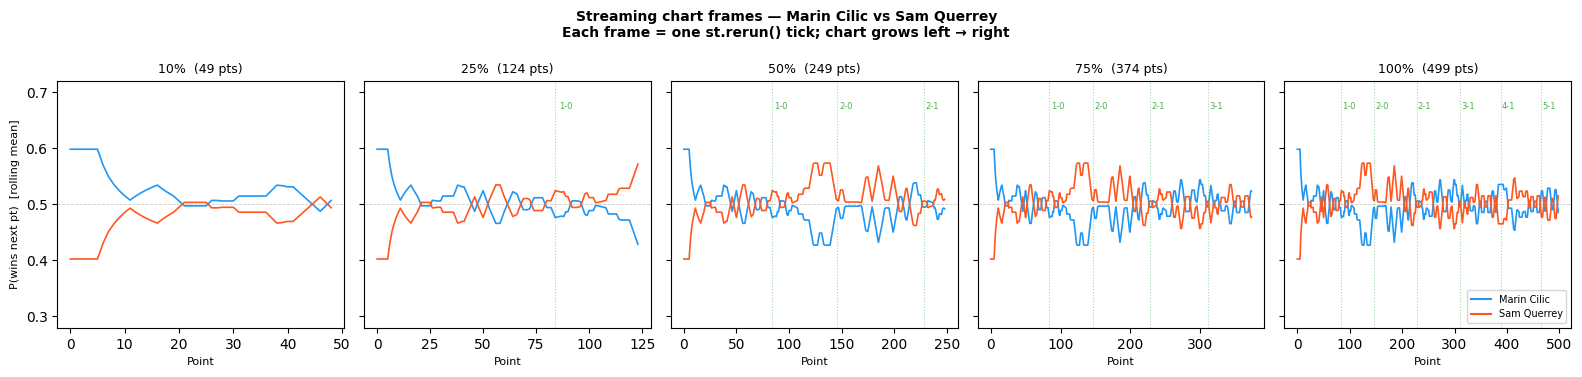

In [13]:
SNAPSHOTS = [0.10, 0.25, 0.50, 0.75, 1.00]

fig, axes = plt.subplots(1, len(SNAPSHOTS), figsize=(16, 3.8), sharey=True)
fig.suptitle(
    f"Streaming chart frames — {p1_name} vs {p2_name}\n"
    "Each frame = one st.rerun() tick; chart grows left → right",
    fontsize=10, fontweight="bold"
)

for ax, frac in zip(axes, SNAPSHOTS):
    cutoff  = max(WINDOW, int(len(odds_df) * frac))
    sl      = odds_df.iloc[:cutoff]
    p1_s    = sl["p1_win_prob"].rolling(WINDOW, min_periods=1).mean()
    p2_s    = sl["p2_win_prob"].rolling(WINDOW, min_periods=1).mean()

    ax.plot(p1_s.values, color="#2196F3", linewidth=1.2)
    ax.plot(p2_s.values, color="#FF5722", linewidth=1.2)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)

    for pt, score in set_boundaries:
        if pt < cutoff:
            ax.axvline(pt, color="#4CAF50", linestyle=":", alpha=0.5, linewidth=0.8)
            ax.text(pt + 2, 0.67, f"{score[0]}-{score[1]}", fontsize=6, color="#4CAF50")

    ax.set_title(f"{int(frac * 100)}%  ({cutoff} pts)", fontsize=9)
    ax.set_ylim(0.28, 0.72)
    ax.set_xlabel("Point", fontsize=8)

axes[0].set_ylabel("P(wins next pt)  [rolling mean]", fontsize=8)
axes[-1].plot([], [], color="#2196F3", label=p1_name)
axes[-1].plot([], [], color="#FF5722", label=p2_name)
axes[-1].legend(loc="lower right", fontsize=7)

plt.tight_layout()
plt.show()

## 9. app.py Structure Sketch

The design document for `src/tennis_predictor/dashboard/app.py`.
Not runnable here — shows the Streamlit-specific API calls and the
exact code structure that Gate 3 will implement.

**Key Streamlit APIs**:
- `st.session_state` — persist objects across re-renders
- `st.empty()` — in-place chart placeholder (no flicker on update)
- `st.line_chart()` — auto-scaling line chart from a DataFrame
- `st.metric()` — KPI display with delta indicator
- `st.rerun()` — schedule the next re-render tick immediately

In [14]:
APP_STRUCTURE = """
# src/tennis_predictor/dashboard/app.py
# Run: streamlit run src/tennis_predictor/dashboard/app.py

import streamlit as st
from tennis_predictor.ingestion import (
    IngestionConfig, IngestionPipeline,
    EventQueue, GameStateManager, InferenceEngine,
    EventConsumer, OddsPublisher, MatchEventProducer, OddsUpdate,
)

WINDOW = 20   # rolling mean window for win probability and latency

# ── 1. Load heavy singletons once ────────────────────────────────────────────
if "pipeline" not in st.session_state:
    config = IngestionConfig(processed_csv=..., model_path=..., player_mapping_path=...)
    st.session_state["pipeline"] = IngestionPipeline(config)
    st.session_state["engine"]   = st.session_state["pipeline"]._engine
    st.session_state["catalogue"]= build_catalogue(st.session_state["pipeline"])

pipeline  = st.session_state["pipeline"]
catalogue = st.session_state["catalogue"]

# ── 2. Sidebar controls ───────────────────────────────────────────────────────
with st.sidebar:
    st.title("Tennis Live Odds")
    match_id = st.selectbox("Match", catalogue["match_id"],
                            format_func=lambda m: catalogue.set_index("match_id").loc[m, "label"])
    speed    = st.slider("Speed", 0.1, 10.0, 1.0, 0.1)
    col1, col2 = st.columns(2)
    start = col1.button("Play")
    stop  = col2.button("Pause")

# ── 3. Match initialisation ───────────────────────────────────────────────────
if st.session_state.get("match_id") != match_id:
    match_df  = pipeline._df_states[pipeline._df_states["match_id"] == match_id]
    p1, p2    = match_df["player_1"].iloc[0], match_df["player_2"].iloc[0]
    p1_enc    = pipeline._player_mapping["player_1"].get(p1, 0)
    p2_enc    = pipeline._player_mapping["player_2"].get(p2, 0)
    events    = list(MatchEventProducer(match_df).produce())
    eq        = EventQueue(max_size=len(events) + 10)
    for ev in events:
        eq.push(ev)
    st.session_state.update(dict(
        match_id=match_id, p1_name=p1, p2_name=p2,
        queue=eq,
        state_manager=GameStateManager(p1_enc, p2_enc),
        publisher=OddsPublisher(),
        current_event=None, running=False,
    ))

# ── 4. Streaming tick (one event per re-render) ───────────────────────────────
if start: st.session_state["running"] = True
if stop:  st.session_state["running"] = False

if st.session_state["running"] and not st.session_state["queue"].is_empty():
    ev = st.session_state["queue"].pop(timeout_ms=0)
    if ev:
        st.session_state["state_manager"].apply_event(ev)
        fv       = st.session_state["state_manager"].to_feature_vector()
        p_srv, _ = st.session_state["engine"].predict(fv)
        p1_pt    = p_srv if ev.server == 1 else 1 - p_srv
        st.session_state["publisher"].publish(
            OddsUpdate(ev.match_id, ev.point_index, p1_pt, 1-p1_pt, p_srv, 0.0)
        )
        st.session_state["current_event"] = ev

# ── 5. Render ─────────────────────────────────────────────────────────────────
odds_df = st.session_state["publisher"].to_dataframe()
p1_name = st.session_state["p1_name"]
p2_name = st.session_state["p2_name"]

# Main chart
chart_ph = st.empty()
if not odds_df.empty:
    smoothed = odds_df[["p1_win_prob", "p2_win_prob"]].rolling(WINDOW, min_periods=1).mean()
    smoothed.columns = [p1_name, p2_name]
    chart_ph.line_chart(smoothed)

# Score ticker (sidebar)
ev = st.session_state.get("current_event")
if ev:
    with st.sidebar:
        st.metric(p1_name, fmt_score(ev, 1))
        st.metric(p2_name, fmt_score(ev, 2))
        st.caption(fmt_server(ev, p1_name, p2_name))

# Latency panel
if not odds_df.empty:
    rolling_lat = odds_df["latency_ms"].tail(WINDOW).mean()
    st.metric("Inference latency (rolling mean)", f"{rolling_lat:.3f} ms")

# ── 6. Schedule next tick ─────────────────────────────────────────────────────
if st.session_state["running"]:
    st.rerun()   # triggers the next re-render immediately
"""

print("app.py structure:")
print(f"  Sections: 6")
print(f"  Lines:    {len(APP_STRUCTURE.strip().splitlines())}")
print()
print("Section breakdown:")
for sec in [
    "1. Load heavy singletons once (ONNX, CSV, player mapping)",
    "2. Sidebar controls (match selector, speed slider, play/pause)",
    "3. Match initialisation (reset queue + state on new selection)",
    "4. Streaming tick (one event per st.rerun())",
    "5. Render (chart, score ticker, latency metric)",
    "6. Schedule next tick (st.rerun() if running)",
]:
    print(f"  {sec}")

app.py structure:
  Sections: 6
  Lines:    94

Section breakdown:
  1. Load heavy singletons once (ONNX, CSV, player mapping)
  2. Sidebar controls (match selector, speed slider, play/pause)
  3. Match initialisation (reset queue + state on new selection)
  4. Streaming tick (one event per st.rerun())
  5. Render (chart, score ticker, latency metric)
  6. Schedule next tick (st.rerun() if running)


## 10. Summary

### Components prototyped

| Component | Prototype (this notebook) | Dashboard (`app.py`) |
|---|---|---|
| Match selector | pandas groupby → ranked table | `st.selectbox` over `match_catalogue` |
| Live chart | matplotlib, full replay | `st.line_chart` + `st.empty()`, grows per tick |
| Smoothing | rolling mean WINDOW=20 | same — applied before `st.line_chart` |
| Score ticker | `fmt_score()` printed | `st.sidebar.metric()` per player |
| Latency panel | rolling mean table | `st.metric()` with delta indicator |
| Set annotations | vertical green lines | same, via Plotly `add_vline()` |
| Break markers | scatter on chart | same, via Plotly `add_scatter()` |
| Session state | Python dict schema | `st.session_state` — identical keys |
| Streaming loop | frame-by-frame simulation | `st.rerun()` loop, one event per tick |

### Key architectural decisions

1. **Load once**: `IngestionPipeline` (CSV + ONNX + mapping) in `st.session_state` at app start — not per re-render.
2. **One event per tick**: `queue.pop()` + `state.apply_event()` + `engine.predict()` per `st.rerun()`. Cost: ~0.01 ms — 1,600× under Streamlit's 16 ms frame budget.
3. **Smoothing at render time**: rolling mean applied on the full `OddsPublisher.to_dataframe()` output before passing to `st.line_chart`. The publisher stores raw values — smoothing is a display concern.
4. **`st.empty()` for in-place updates**: avoids chart re-mounting, preventing flicker.

### Next step — Gate 3

Build the runnable Streamlit app at:
```
src/tennis_predictor/dashboard/
├── __init__.py
└── app.py
```

Launch with:
```bash
uv run streamlit run src/tennis_predictor/dashboard/app.py
```